# Phase 2 — Exploratory Data Analysis (EDA)
This notebook explores the Pfand 2022 master dataset through visual and numerical analysis. 
The goal is to identify patterns, compare materials, understand recycling performance, 
and prepare insights for later ESG modeling and dashboard creation.

In [27]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Create output folder (run once, safe to keep here)
os.makedirs("../outputs/phase2_charts", exist_ok=True)

# Load master dataset
master = pd.read_csv("../data/cleaned/pfand_2022_master.csv")

# Clean numeric columns
def clean_numeric(col):
    return (
        col.astype(str)
        .str.replace(",", ".", regex=False)
        .str.strip()
        .replace("", None)
        .astype(float)
    )

master["pfand_input_kt"] = clean_numeric(master["pfand_input_kt"])
master["total_recycled_kt"] = clean_numeric(master["total_recycled_kt"])
master["recycling_rate_pct"] = clean_numeric(master["recycling_rate_pct"])

display(master)


,material,pfand_input_kt,total_recycled_kt,recycling_rate_pct
0,Glas,35.4,35.1,99.2
1,Eisenmetalle,26.7,26.6,99.5
2,Aluminium,50.4,50.0,99.2
3,Kunststoff,463.5,441.7,95.3
4,Papier_Pappe_Karton,9.0,NaN,NaN
5,Fluessigkeitskarton,NaN,NaN,NaN


## Step 2 — Material Input vs Material Recycled (kt)
This chart compares the total Pfand input volume with the amount actually recycled.


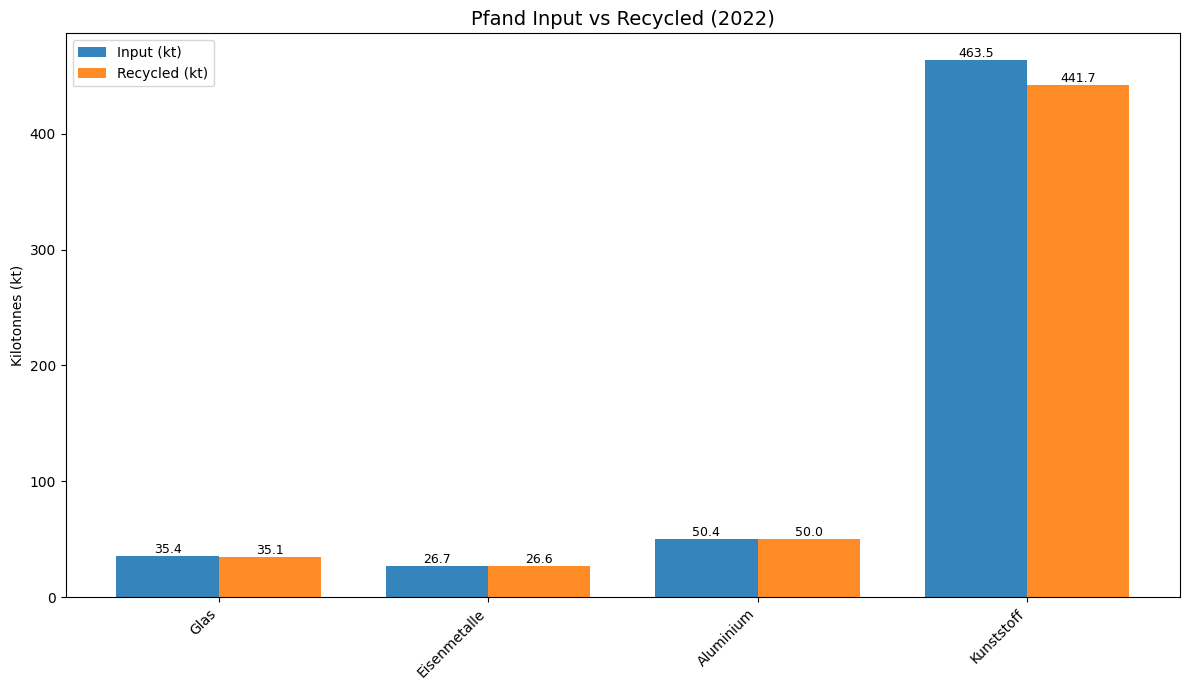

In [ ]:
## Step 3 — Material Input vs Recycled (kt) (GROUPED, FIXED)

import numpy as np
import matplotlib.pyplot as plt

# Keep only rows that have both values (prevents NaN/blank issues)
plot_df = master.dropna(subset=["material", "pfand_input_kt", "total_recycled_kt"]).copy()
plot_df = plot_df[plot_df["pfand_input_kt"] > 0]

materials = plot_df["material"].astype(str).tolist()
x = np.arange(len(materials))
width = 0.38

plt.figure(figsize=(12,7))

bars_input = plt.bar(
    x - width/2,
    plot_df["pfand_input_kt"],
    width=width,
    label="Input (kt)",
    alpha=0.9
)

bars_recycled = plt.bar(
    x + width/2,
    plot_df["total_recycled_kt"],
    width=width,
    label="Recycled (kt)",
    alpha=0.9
)

plt.title("Pfand Input vs Recycled (2022)", fontsize=14)
plt.ylabel("Kilotonnes (kt)")
plt.xticks(ticks=x, labels=materials, rotation=45, ha="right")

# Annotate BOTH bars
def add_labels(bars):
    for b in bars:
        h = b.get_height()
        plt.text(
            b.get_x() + b.get_width()/2,
            h,
            f"{h:.1f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

add_labels(bars_input)
add_labels(bars_recycled)

plt.legend()
plt.tight_layout()
plt.savefig(
    "../outputs/phase2_charts/<descriptive_filename>.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## Step 4 — Recycling Rate (%) by Material

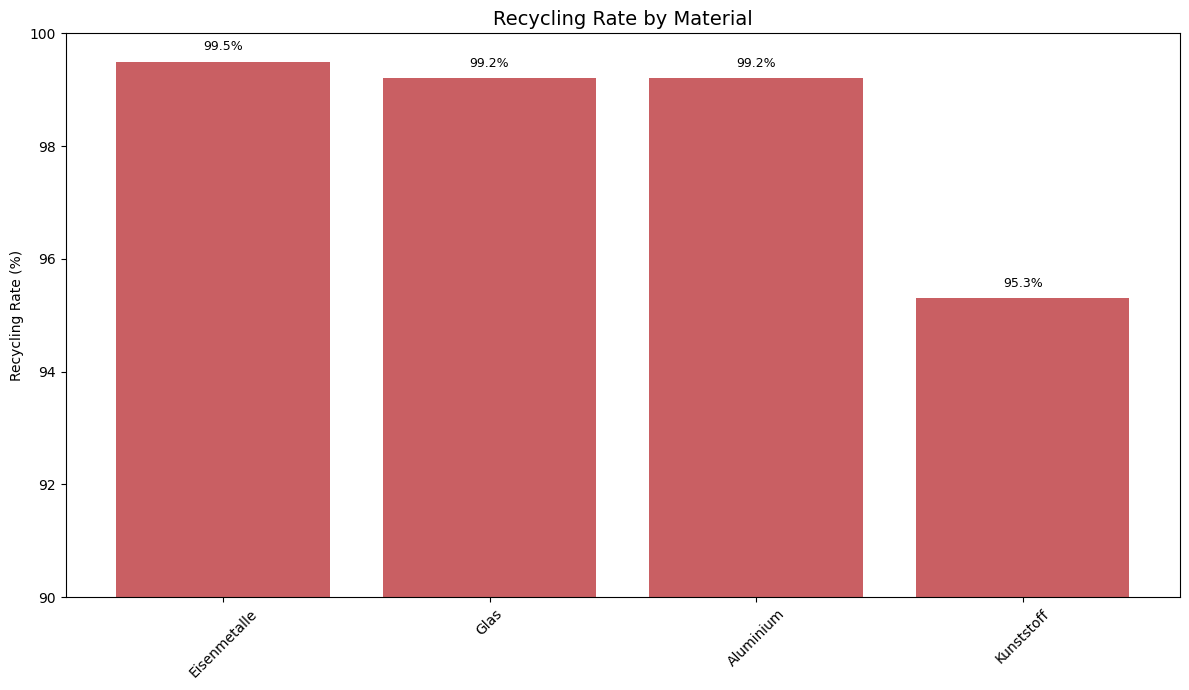

In [ ]:
## Step 4 — Recycling Rate (%) by Material

plt.figure(figsize=(12,7))

# SORT values (better visually)
rates_sorted = master.sort_values("recycling_rate_pct", ascending=False)

plt.bar(rates_sorted["material"], rates_sorted["recycling_rate_pct"], 
        color="#C44E52", alpha=0.9)

plt.title("Recycling Rate by Material", fontsize=14)
plt.ylabel("Recycling Rate (%)")
plt.xticks(rotation=45)

# Zoom y-axis for clarity
plt.ylim(90, 100)

# Annotate bars
for i, v in enumerate(rates_sorted["recycling_rate_pct"]):
    plt.text(i, v+0.2, f"{v:.1f}%", fontsize=9, ha="center")

plt.tight_layout()
plt.savefig(
    "../outputs/phase2_charts/<descriptive_filename>.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## Step 5 — Material Share of Pfand Input


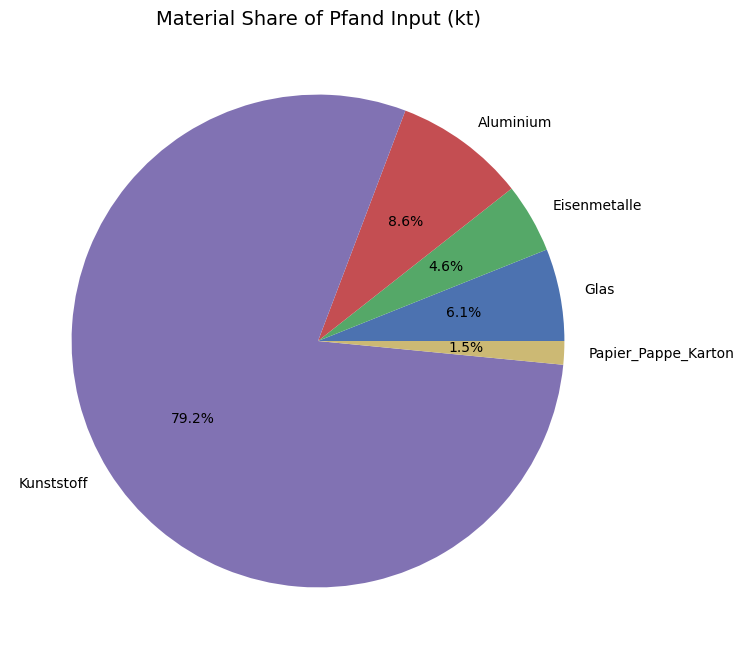

In [ ]:
## Step 5 — Material Share of Pfand Input (kt)

valid_input = master.dropna(subset=["pfand_input_kt"])

plt.figure(figsize=(8,8))
plt.pie(valid_input["pfand_input_kt"], 
        labels=valid_input["material"],
        autopct="%1.1f%%",
        colors=["#4C72B0","#55A868","#C44E52","#8172B3","#CCB974","#64B5CD"])
plt.title("Material Share of Pfand Input (kt)", fontsize=14)
plt.savefig(
    "../outputs/phase2_charts/<descriptive_filename>.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## Step 6 — Ranking of Materials by Recycling Rate


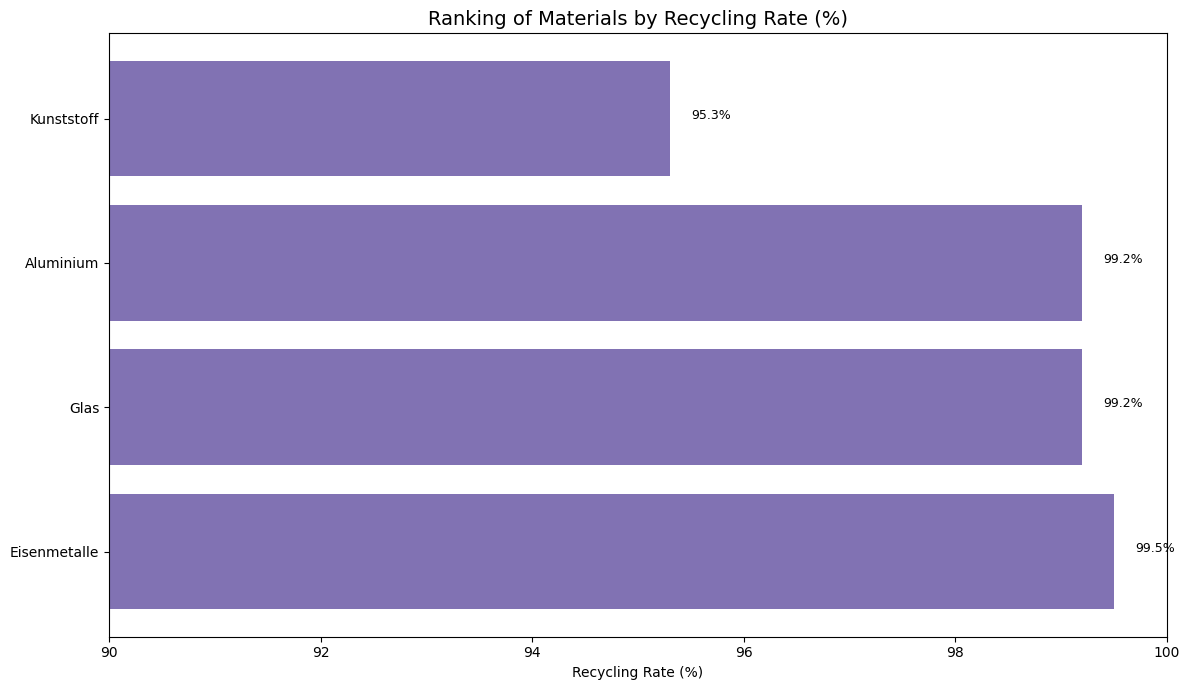

In [ ]:
## Step 6 — Ranking of Recycling Rates

plt.figure(figsize=(12,7))

plt.barh(rates_sorted["material"], 
         rates_sorted["recycling_rate_pct"],
         color="#8172B3")

plt.title("Ranking of Materials by Recycling Rate (%)", fontsize=14)
plt.xlabel("Recycling Rate (%)")

# Zoom in to highlight differences
plt.xlim(90, 100)

# Annotate
for i, v in enumerate(rates_sorted["recycling_rate_pct"]):
    plt.text(v+0.2, i, f"{v:.1f}%", fontsize=9)

plt.tight_layout()
plt.savefig(
    "../outputs/phase2_charts/<descriptive_filename>.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## Step 7 — Relationship Between Input Volume and Recycling Rate


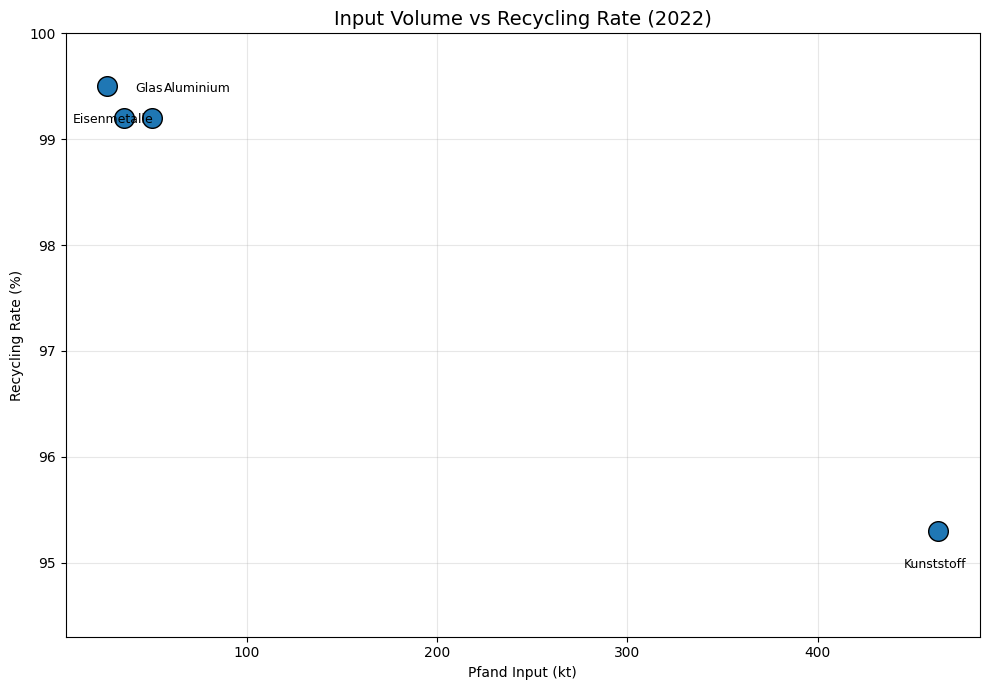

In [ ]:
## Step 7 — Input vs Recycling Rate (Scatter) (FIXED)

import numpy as np
import matplotlib.pyplot as plt

# 1) Keep only rows that can actually be plotted
plot_df = master.dropna(subset=["pfand_input_kt", "recycling_rate_pct", "material"]).copy()
plot_df = plot_df[plot_df["pfand_input_kt"] > 0]

plt.figure(figsize=(10,7))

plt.scatter(
    plot_df["pfand_input_kt"],
    plot_df["recycling_rate_pct"],
    s=200,
    edgecolors="black"   # safer than edgecolor=
)

# 2) Smarter label offsets (alternating) to reduce overlap
for i, row in plot_df.reset_index(drop=True).iterrows():
    dx = 6 if i % 2 == 0 else -18
    dy = 0.25 if i % 2 == 0 else -0.35
    plt.text(
        row["pfand_input_kt"] + dx,
        row["recycling_rate_pct"] + dy,
        str(row["material"]),
        fontsize=9
    )

plt.xlabel("Pfand Input (kt)")
plt.ylabel("Recycling Rate (%)")
plt.title("Input Volume vs Recycling Rate (2022)", fontsize=14)

# 3) Dynamic y-limits so it doesn't clip if your numbers change later
ymin = max(0, plot_df["recycling_rate_pct"].min() - 1)
ymax = min(100, plot_df["recycling_rate_pct"].max() + 1)
plt.ylim(ymin, ymax)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "../outputs/phase2_charts/<descriptive_filename>.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## Step 8 — TOMRA Global Benchmark Dataset


In [20]:
import pandas as pd

tomra_data = {
    "country": [
        "Finland", "Germany", "Denmark", "Norway", "Lithuania",
        "Slovakia", "Estonia", "Iceland", "Sweden", "Oregon (USA)"
    ],
    "return_rate_pct": [
        99, 98, 93, 92, 90,
        90, 89, 89, 88, 87
    ],
    "deposit_value_eur": [
        "€0.10-0.40", "€0.25", "€0.13-0.40", "€0.20-0.30", "€0.10",
        "€0.15", "€0.10", "€0.14", "€0.09-0.18", "€0.085"
    ]
}

tomra_df = pd.DataFrame(tomra_data)
display(tomra_df)


,country,return_rate_pct,deposit_value_eur
0,Finland,99,€0.10-0.40
1,Germany,98,€0.25
2,Denmark,93,€0.13-0.40
3,Norway,92,€0.20-0.30
4,Lithuania,90,€0.10
5,Slovakia,90,€0.15
6,Estonia,89,€0.10
7,Iceland,89,€0.14
8,Sweden,88,€0.09-0.18
9,Oregon (USA),87,€0.085


## Step 9 — Global Return Rate Comparison (TOMRA Benchmark)


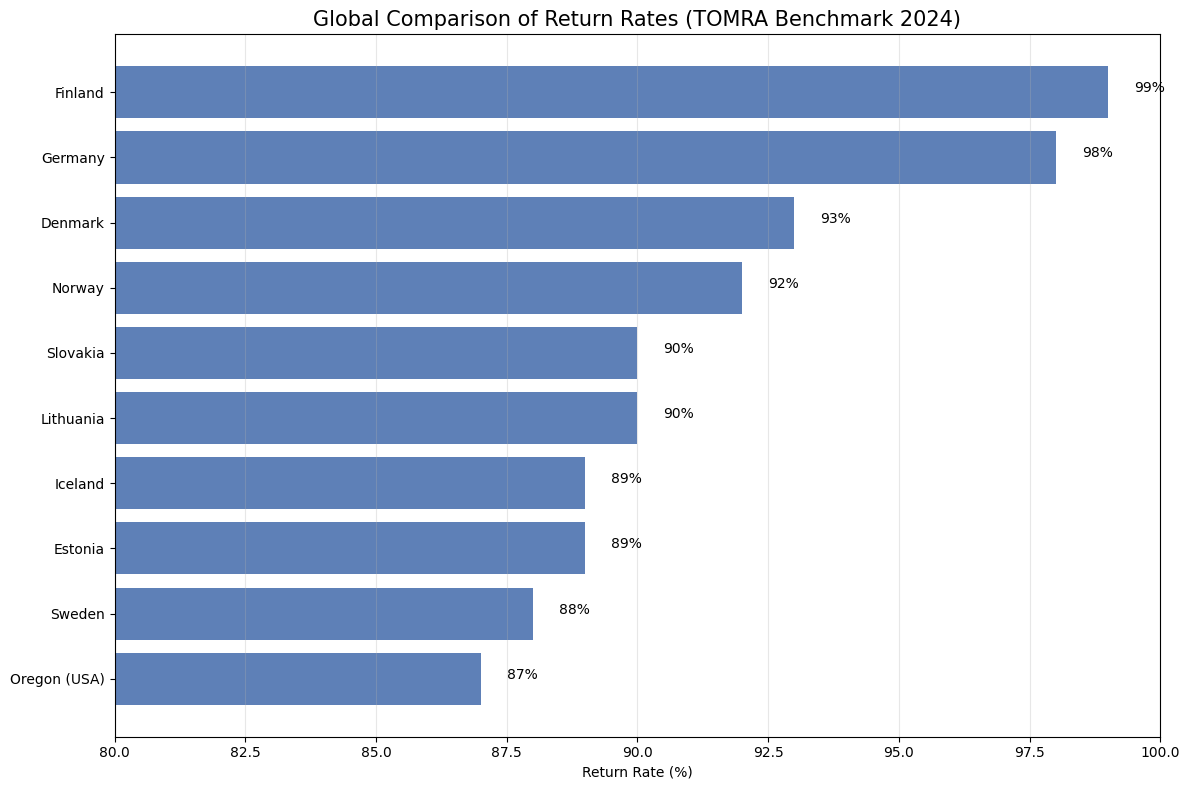

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sorted_df = tomra_df.sort_values("return_rate_pct", ascending=True)

plt.barh(
    sorted_df["country"],
    sorted_df["return_rate_pct"],
    color="#4C72B0",
    alpha=0.9
)

plt.title("Global Comparison of Return Rates (TOMRA Benchmark 2024)", fontsize=15)
plt.xlabel("Return Rate (%)")

# Annotate values on bars
for i, v in enumerate(sorted_df["return_rate_pct"]):
    plt.text(v + 0.5, i, f"{v}%", fontsize=10)

plt.xlim(80, 100)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(
    "../outputs/phase2_charts/<descriptive_filename>.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## Step 10 — Deposit Value vs Return Rate (Global Correlation)


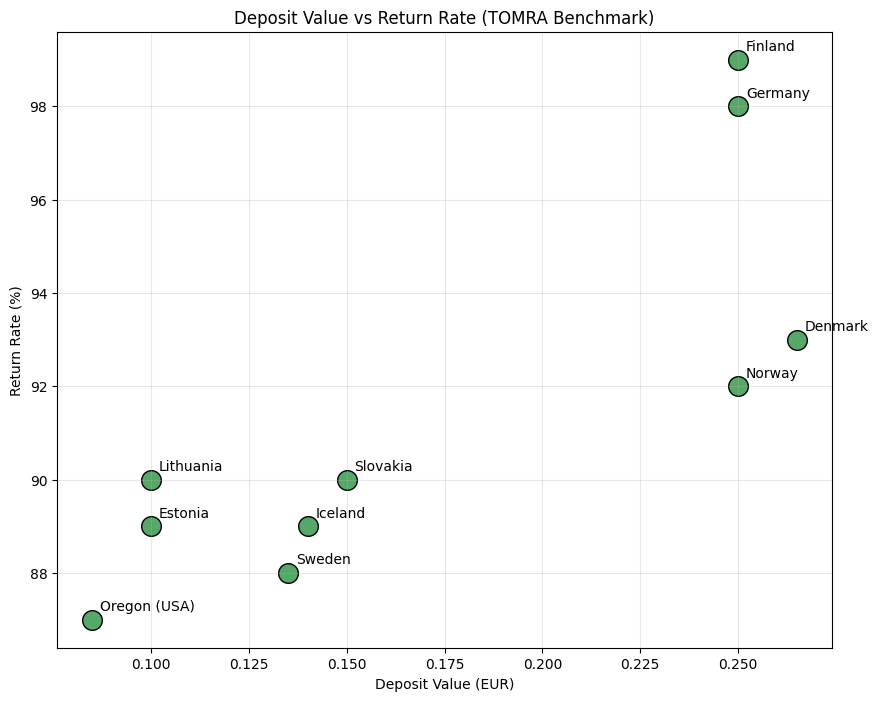

In [ ]:
plt.figure(figsize=(10,8))

# Convert deposit values to midpoint numbers for scatter plot
def mid_value(d):
    if "-" in d:
        a, b = d.replace("€", "").split("-")
        return (float(a) + float(b)) / 2
    else:
        return float(d.replace("€", ""))

tomra_df["deposit_mid"] = tomra_df["deposit_value_eur"].apply(mid_value)

plt.scatter(tomra_df["deposit_mid"], tomra_df["return_rate_pct"], s=200, color="#55A868", edgecolor="black")

for _, row in tomra_df.iterrows():
    plt.text(row["deposit_mid"] + 0.002, row["return_rate_pct"] + 0.2, row["country"], fontsize=10)

plt.xlabel("Deposit Value (EUR)")
plt.ylabel("Return Rate (%)")
plt.title("Deposit Value vs Return Rate (TOMRA Benchmark)")
plt.grid(alpha=0.3)
plt.savefig(
    "../outputs/phase2_charts/<descriptive_filename>.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
